In [4]:
import os

# Set working directory to project root
project_root = "/Users/mithil/workspace/cs_321M/cs_321m_project/cs321m-rag-study"
os.chdir(project_root)
print(f"Working directory set to: {os.getcwd()}")

# Verify key files are visible
from pathlib import Path
files = [
    "outputs/phase1/coverage/corpus_embeddings.npy",
    "outputs/phase1/coverage/query_embeddings.npy",
    "data/indexes/dense/metadata.jsonl",
]
for f in files:
    print(f"{'OK' if Path(f).exists() else 'MISSING'} -- {f}")

Working directory set to: /Users/mithil/workspace/cs_321M/cs_321m_project/cs321m-rag-study
OK -- outputs/phase1/coverage/corpus_embeddings.npy
OK -- outputs/phase1/coverage/query_embeddings.npy
OK -- data/indexes/dense/metadata.jsonl


# Phase 1: Semantic Coverage Analysis
## Enterprise RAG Benchmark Validity Project — Stanford CS321M

This notebook conducts the semantic coverage analysis for Phase 1 of the project.
It takes pre-computed embeddings as input and answers two research questions:

- **RQ1 — Corpus Coverage:** Does the question bank cover the document corpus, or are there large regions that no question ever touches?
- **RQ2 — Query Redundancy:** Are the questions in the question bank semantically diverse, or are they clustered into a small number of redundant groups?

**Inputs:**
- `outputs/phase1/coverage/corpus_embeddings.npy` — 18,840 corpus chunk embeddings
- `outputs/phase1/coverage/query_embeddings.npy` — 100 query embeddings
- `outputs/phase1/coverage/query_index.json` — query ID and text lookup
- `data/indexes/dense/metadata.jsonl` — corpus chunk metadata

**This notebook is for exploration. A production script will be generated after analysis is finalized.**

In [5]:
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity, pairwise_distances
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

# Display settings
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["font.size"] = 11

print("Imports OK")

Imports OK


## 1. Load Data

In [6]:
# Load corpus embeddings
corpus_embeddings = np.load("outputs/phase1/coverage/corpus_embeddings.npy")
print(f"Corpus embeddings: {corpus_embeddings.shape}")

# Load query embeddings
query_embeddings = np.load("outputs/phase1/coverage/query_embeddings.npy")
print(f"Query embeddings:  {query_embeddings.shape}")

# Load query index
with open("outputs/phase1/coverage/query_index.json") as f:
    query_index = json.load(f)
query_texts = [q["question"] for q in query_index]
query_ids = [q["question_id"] for q in query_index]

# Load corpus metadata
metadata = []
with open("data/indexes/dense/metadata.jsonl") as f:
    for line in f:
        metadata.append(json.loads(line))
print(f"Corpus metadata records: {len(metadata)}")

# Load full question objects
with open("data/processed/subsets/openrag_text_only_100.json") as f:
    questions = json.load(f)
print(f"Questions loaded: {len(questions)}")

print("\nAll data loaded successfully.")

Corpus embeddings: (18840, 384)
Query embeddings:  (100, 384)
Corpus metadata records: 18840
Questions loaded: 100

All data loaded successfully.


## 2. K Selection — Elbow Method (RQ1: Corpus Clustering)

We need to choose how many clusters to divide the corpus into.
We run k-means for k = 10 to 100 and look for the "elbow" —
the point where adding more clusters stops reducing inertia meaningfully.

**This cell will take 3-5 minutes on a MacBook.**

In [7]:
k_values = list(range(10, 105, 5))
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(corpus_embeddings)
    inertias.append(km.inertia_)
    print(f"k={k:3d}  inertia={km.inertia_:.2f}")

# Detect elbow via second derivative
diffs1 = np.diff(inertias)
diffs2 = np.diff(diffs1)
elbow_idx = np.argmax(diffs2) + 1
elbow_k = k_values[elbow_idx]
print(f"\nElbow detected at k = {elbow_k}")

k= 10  inertia=13586.09
k= 15  inertia=12936.14
k= 20  inertia=12476.52
k= 25  inertia=12144.16
k= 30  inertia=11925.98
k= 35  inertia=11714.71
k= 40  inertia=11498.29
k= 45  inertia=11286.77
k= 50  inertia=11120.16
k= 55  inertia=10932.26
k= 60  inertia=10742.76
k= 65  inertia=10615.31
k= 70  inertia=10507.15
k= 75  inertia=10259.86
k= 80  inertia=10241.21
k= 85  inertia=10043.40
k= 90  inertia=9920.34
k= 95  inertia=9801.66
k=100  inertia=9654.00

Elbow detected at k = 75


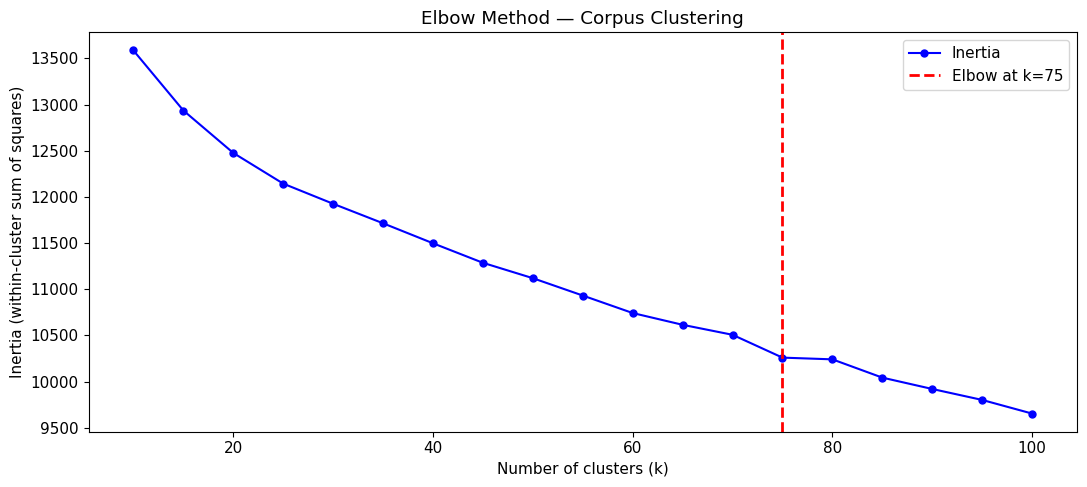

Selected K_CORPUS = 75


In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(k_values, inertias, "bo-", markersize=5, label="Inertia")
ax.axvline(x=elbow_k, color="red", linestyle="--",
           linewidth=2, label=f"Elbow at k={elbow_k}")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia (within-cluster sum of squares)")
ax.set_title("Elbow Method — Corpus Clustering")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/phase1/coverage/elbow_corpus.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Selected K_CORPUS = {elbow_k}")

## 2. Dimensionality Reduction for Visualization
We reduce the 384-dimensional corpus and query embeddings to 2D using two methods:
- **UMAP** — preserves local neighborhood structure, better for clustering validation
- **t-SNE** — independent nonlinear method, used as visual validation

If both methods show similar structure, we can trust what we're seeing.
We overlay the 100 queries on top of the corpus to get an immediate sense of coverage.

In [9]:
import subprocess
subprocess.run(["pip", "install", "umap-learn", "--quiet"])
import umap
from sklearn.manifold import TSNE
print("UMAP and t-SNE ready")

UMAP and t-SNE ready


### 2a. UMAP 2D Visualization

In [10]:
import umap
import numpy as np
import matplotlib.pyplot as plt

print("Fitting UMAP on corpus embeddings (this takes 2-4 minutes)...")
reducer_umap = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
    verbose=True
)

# Fit on corpus, transform both corpus and queries
corpus_2d_umap = reducer_umap.fit_transform(corpus_embeddings)
query_2d_umap = reducer_umap.transform(query_embeddings)

print(f"Corpus 2D shape: {corpus_2d_umap.shape}")
print(f"Query 2D shape:  {query_2d_umap.shape}")

# Save for reuse
np.save("outputs/phase1/coverage/corpus_2d_umap.npy", corpus_2d_umap)
np.save("outputs/phase1/coverage/query_2d_umap.npy", query_2d_umap)
print("UMAP 2D embeddings saved.")

Fitting UMAP on corpus embeddings (this takes 2-4 minutes)...
UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, random_state=42, verbose=True)
Mon May 25 18:49:11 2026 Construct fuzzy simplicial set
Mon May 25 18:49:11 2026 Finding Nearest Neighbors
Mon May 25 18:49:11 2026 Building RP forest with 12 trees
Mon May 25 18:49:12 2026 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	Stopping threshold met -- exiting after 3 iterations
Mon May 25 18:49:16 2026 Finished Nearest Neighbor Search
Mon May 25 18:49:17 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon May 25 18:49:30 2026 Finished embedding
Mon May 25 18:49:30 2026 Building hub-based search tree
Mon May 25 18:49:32 2026 Forward diversification reduced edges from 282600 to 185112
Mon May 25 18:49:32 2026 Reverse diversification reduced edges from 185112 to 185112
Mon May 25 18:49:33 2026 Degree pruning reduced edges from 223498 to 223322
Mon May 25 18:49:33 2026 Resorting data and graph based on tree order
Mon May 25 18:49:33 2026 Building and compiling search function


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
Corpus 2D shape: (18840, 2)
Query 2D shape:  (100, 2)
UMAP 2D embeddings saved.


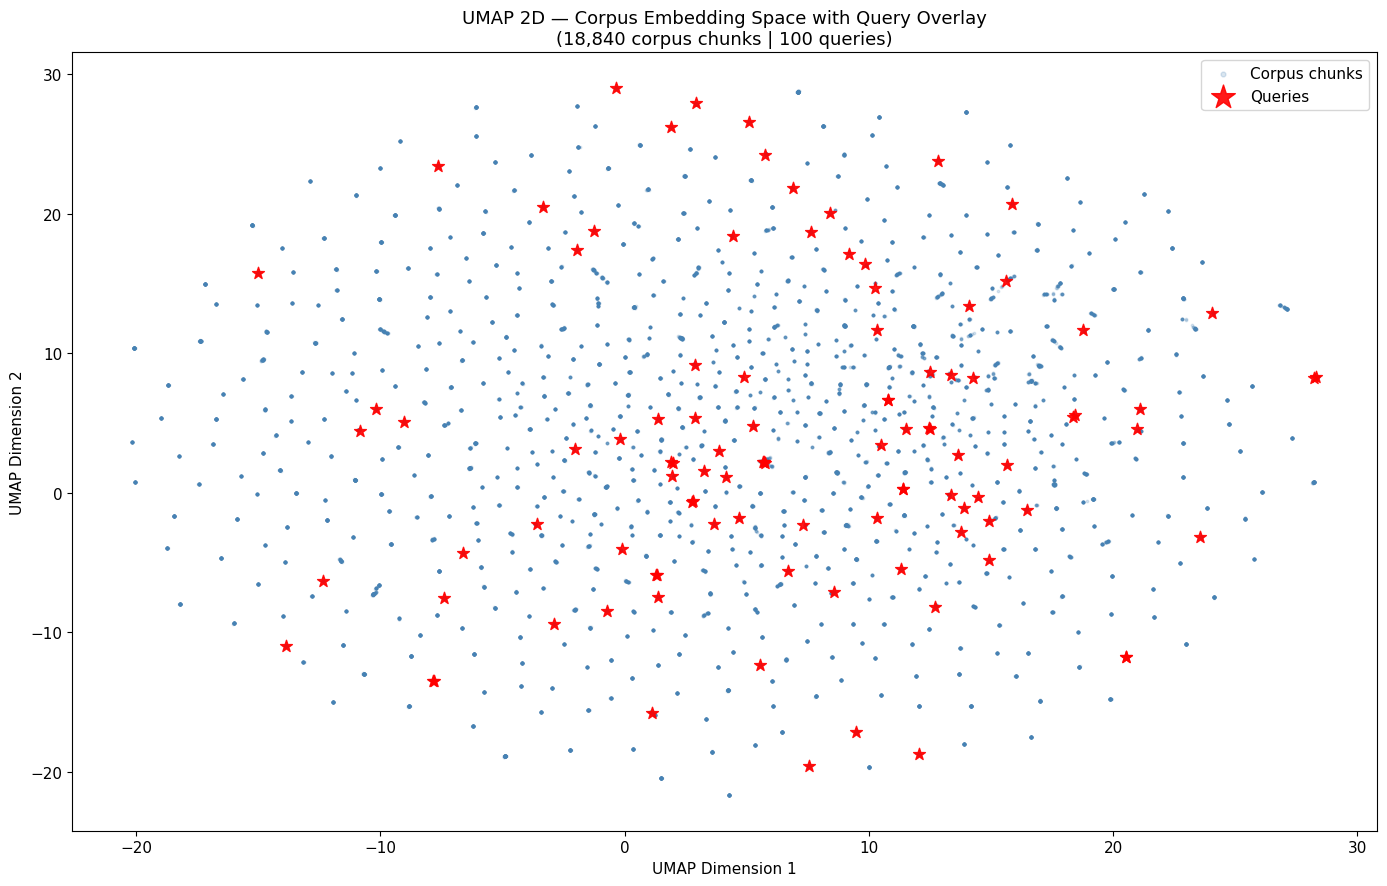

UMAP visualization saved.


In [11]:
fig, ax = plt.subplots(figsize=(14, 9))

# Plot corpus chunks
ax.scatter(
    corpus_2d_umap[:, 0], corpus_2d_umap[:, 1],
    alpha=0.2, s=3, c="steelblue", label="Corpus chunks"
)

# Plot queries on top
ax.scatter(
    query_2d_umap[:, 0], query_2d_umap[:, 1],
    alpha=0.9, s=80, c="red", marker="*",
    label="Queries", zorder=5
)

ax.set_title("UMAP 2D — Corpus Embedding Space with Query Overlay\n"
             f"({len(corpus_embeddings):,} corpus chunks | {len(query_embeddings)} queries)",
             fontsize=13)
ax.legend(fontsize=11, markerscale=2)
ax.set_xlabel("UMAP Dimension 1")
ax.set_ylabel("UMAP Dimension 2")
plt.tight_layout()
plt.savefig("outputs/phase1/coverage/umap_2d_coverage.png", dpi=150, bbox_inches="tight")
plt.show()
print("UMAP visualization saved.")

### 2b. t-SNE 2D Visualization
Independent nonlinear dimensionality reduction as a visual validation.
If t-SNE shows similar structure to UMAP, we have higher confidence
in what we're seeing.

**Note:** t-SNE does not support transform() on new points — we
concatenate corpus and queries, fit together, then split.
This takes 3-5 minutes.

In [12]:
from sklearn.manifold import TSNE

# Concatenate corpus and queries — fit together so they share the same space
n_corpus = len(corpus_embeddings)
combined = np.vstack([corpus_embeddings, query_embeddings])

print(f"Running t-SNE on {len(combined):,} points (3-5 minutes)...")
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate="auto",
    init="pca",
    metric="cosine",
    random_state=42,
    verbose=1
)
combined_2d_tsne = tsne.fit_transform(combined)

# Split back
corpus_2d_tsne = combined_2d_tsne[:n_corpus]
query_2d_tsne = combined_2d_tsne[n_corpus:]

np.save("outputs/phase1/coverage/corpus_2d_tsne.npy", corpus_2d_tsne)
np.save("outputs/phase1/coverage/query_2d_tsne.npy", query_2d_tsne)
print("t-SNE complete.")

Running t-SNE on 18,940 points (3-5 minutes)...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 18940 samples in 0.004s...
[t-SNE] Computed neighbors for 18940 samples in 2.219s...
[t-SNE] Computed conditional probabilities for sample 1000 / 18940
[t-SNE] Computed conditional probabilities for sample 2000 / 18940
[t-SNE] Computed conditional probabilities for sample 3000 / 18940
[t-SNE] Computed conditional probabilities for sample 4000 / 18940
[t-SNE] Computed conditional probabilities for sample 5000 / 18940
[t-SNE] Computed conditional probabilities for sample 6000 / 18940
[t-SNE] Computed conditional probabilities for sample 7000 / 18940
[t-SNE] Computed conditional probabilities for sample 8000 / 18940
[t-SNE] Computed conditional probabilities for sample 9000 / 18940
[t-SNE] Computed conditional probabilities for sample 10000 / 18940
[t-SNE] Computed conditional probabilities for sample 11000 / 18940
[t-SNE] Computed conditional probabilities for sample 12000 / 18940
[

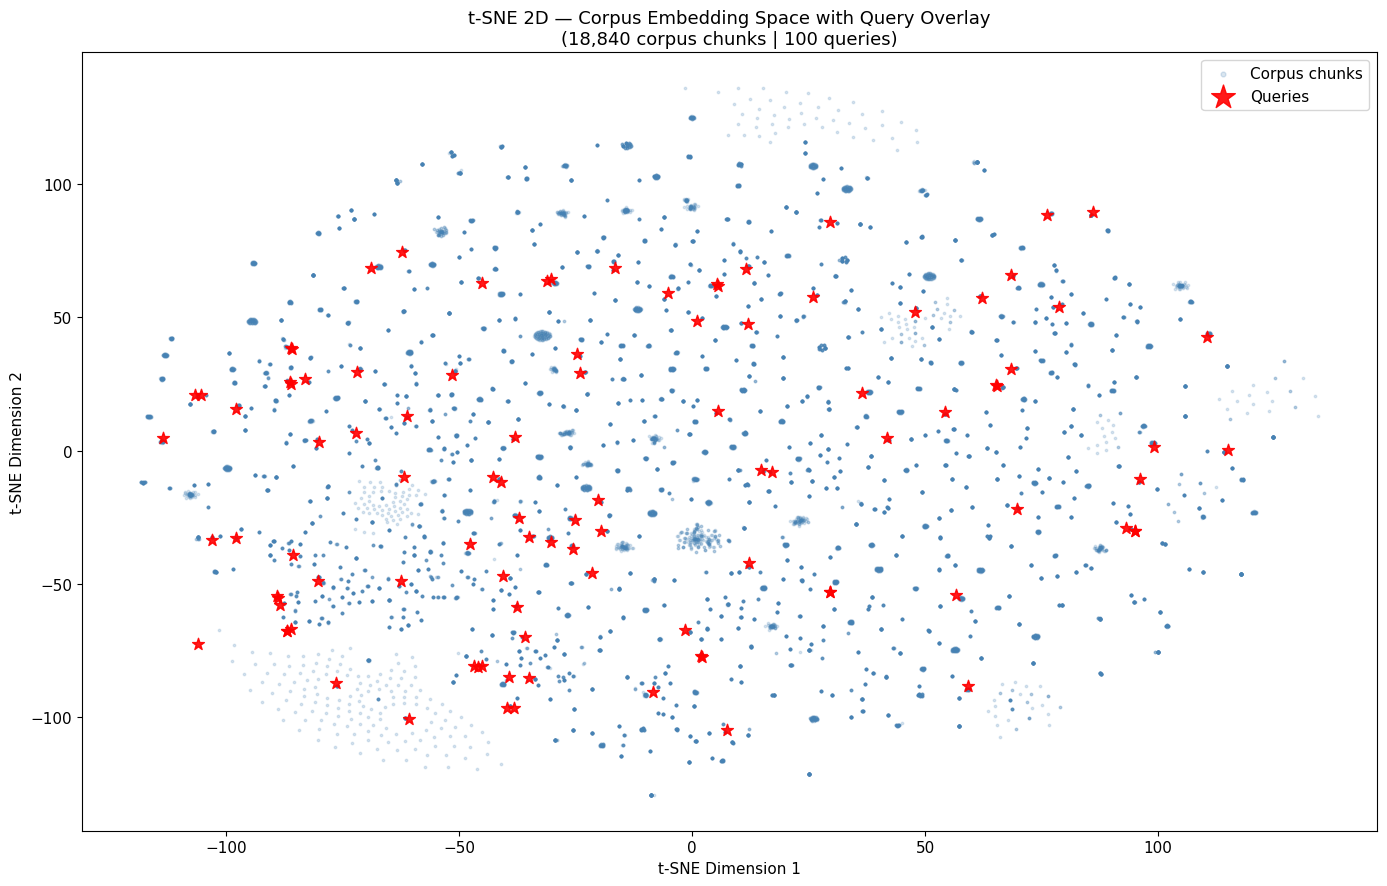

t-SNE visualization saved.


In [13]:
fig, ax = plt.subplots(figsize=(14, 9))

ax.scatter(
    corpus_2d_tsne[:, 0], corpus_2d_tsne[:, 1],
    alpha=0.2, s=3, c="steelblue", label="Corpus chunks"
)
ax.scatter(
    query_2d_tsne[:, 0], query_2d_tsne[:, 1],
    alpha=0.9, s=80, c="red", marker="*",
    label="Queries", zorder=5
)

ax.set_title("t-SNE 2D — Corpus Embedding Space with Query Overlay\n"
             f"({len(corpus_embeddings):,} corpus chunks | {len(query_embeddings)} queries)",
             fontsize=13)
ax.legend(fontsize=11, markerscale=2)
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.savefig("outputs/phase1/coverage/tsne_2d_coverage.png", dpi=150, bbox_inches="tight")
plt.show()
print("t-SNE visualization saved.")

### 2c. Side-by-Side Comparison
Plot UMAP and t-SNE next to each other for direct visual comparison.
Consistent structure across both methods = trustworthy signal.

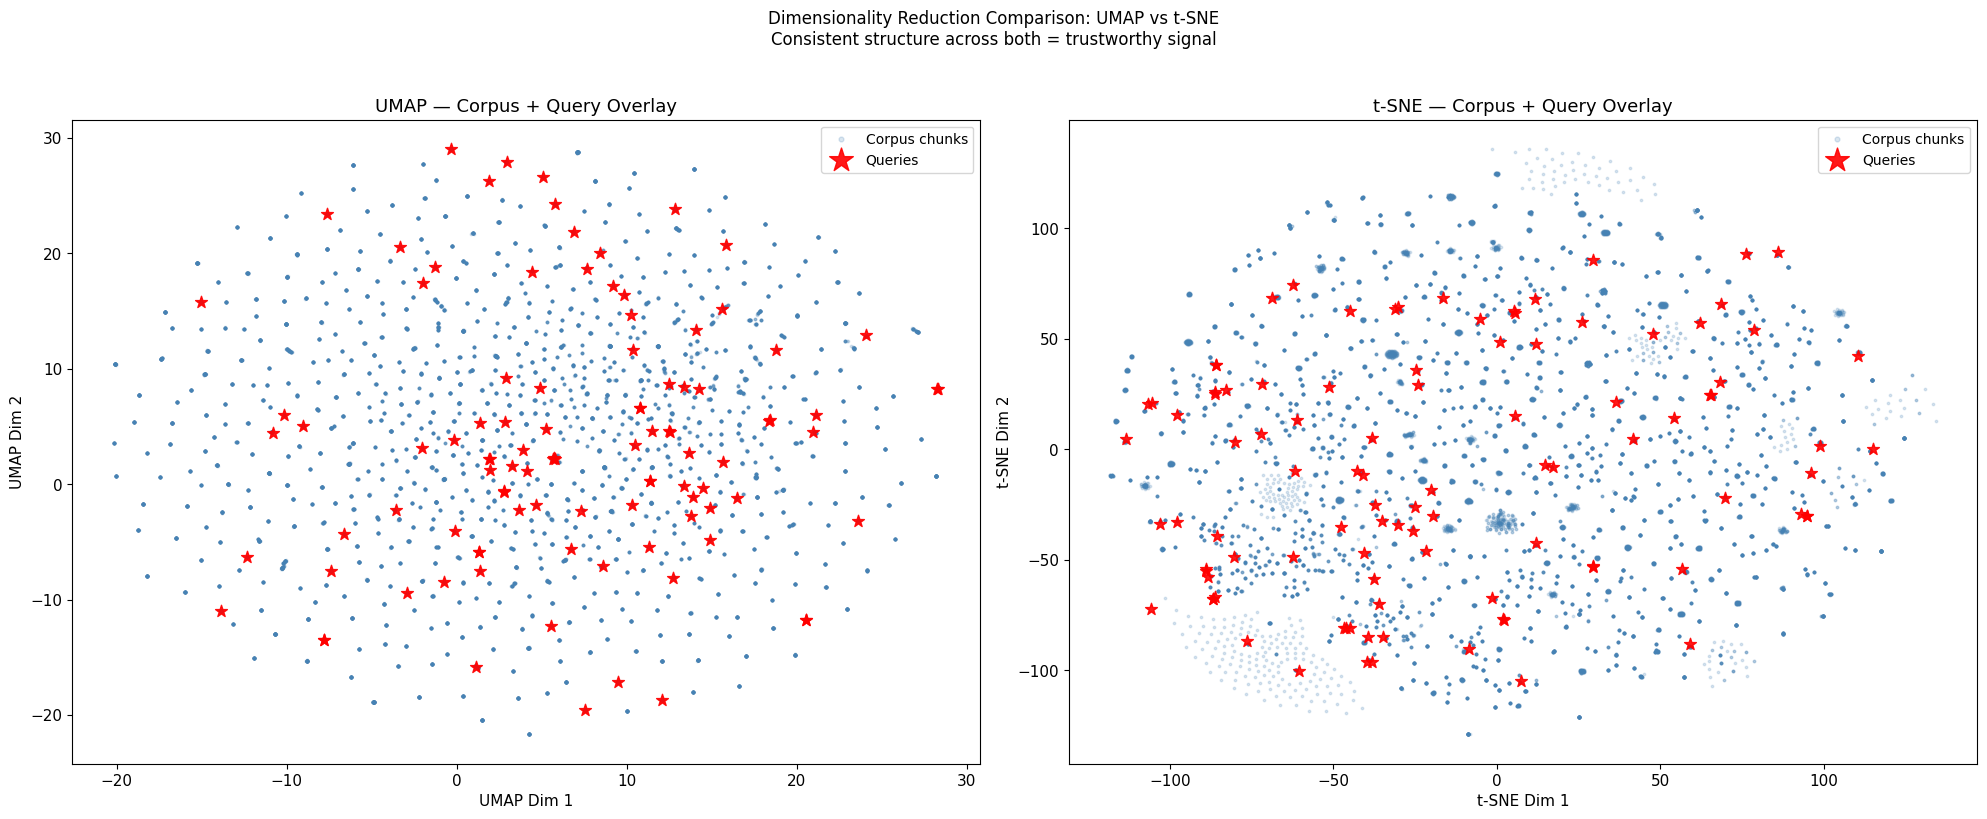

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, corpus_2d, query_2d, title in [
    (axes[0], corpus_2d_umap, query_2d_umap, "UMAP"),
    (axes[1], corpus_2d_tsne, query_2d_tsne, "t-SNE")
]:
    ax.scatter(corpus_2d[:, 0], corpus_2d[:, 1],
               alpha=0.2, s=3, c="steelblue", label="Corpus chunks")
    ax.scatter(query_2d[:, 0], query_2d[:, 1],
               alpha=0.9, s=80, c="red", marker="*",
               label="Queries", zorder=5)
    ax.set_title(f"{title} — Corpus + Query Overlay", fontsize=13)
    ax.legend(fontsize=10, markerscale=2)
    ax.set_xlabel(f"{title} Dim 1")
    ax.set_ylabel(f"{title} Dim 2")

plt.suptitle("Dimensionality Reduction Comparison: UMAP vs t-SNE\n"
             "Consistent structure across both = trustworthy signal",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("outputs/phase1/coverage/umap_vs_tsne_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 3. Extended Elbow Analysis (k = 10 to 500)
Now that we have visual intuition about the corpus structure,
we run the extended elbow to see if any natural cluster count emerges.
We sample k values strategically rather than exhaustively.
**This will take 10-15 minutes.**

In [15]:
from sklearn.cluster import KMeans

# Strategic k sampling — dense early, sparse later
k_values_extended = (
    list(range(10, 105, 5)) +   # Original range
    [150, 200, 250, 300, 400, 500]  # Extended range
)

inertias_extended = []

print("Running extended elbow analysis...")
for k in k_values_extended:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    km.fit(corpus_embeddings)
    inertias_extended.append(km.inertia_)
    print(f"  k={k:4d}  inertia={km.inertia_:.2f}")

# Second derivative elbow detection
diffs1 = np.diff(inertias_extended)
diffs2 = np.diff(diffs1)
elbow_idx = np.argmax(diffs2) + 1
elbow_k_extended = k_values_extended[elbow_idx]
print(f"\nElbow detected at k = {elbow_k_extended}")

Running extended elbow analysis...
  k=  10  inertia=13586.09
  k=  15  inertia=12936.14
  k=  20  inertia=12476.52
  k=  25  inertia=12144.16
  k=  30  inertia=11925.98
  k=  35  inertia=11714.71
  k=  40  inertia=11498.75
  k=  45  inertia=11303.95
  k=  50  inertia=11120.16
  k=  55  inertia=10932.26
  k=  60  inertia=10742.76
  k=  65  inertia=10615.31
  k=  70  inertia=10507.15
  k=  75  inertia=10259.86
  k=  80  inertia=10261.96
  k=  85  inertia=10064.55
  k=  90  inertia=9920.34
  k=  95  inertia=9801.66
  k= 100  inertia=9654.00
  k= 150  inertia=8536.86
  k= 200  inertia=7485.46
  k= 250  inertia=6591.95
  k= 300  inertia=5803.83
  k= 400  inertia=4472.31
  k= 500  inertia=3374.91

Elbow detected at k = 75


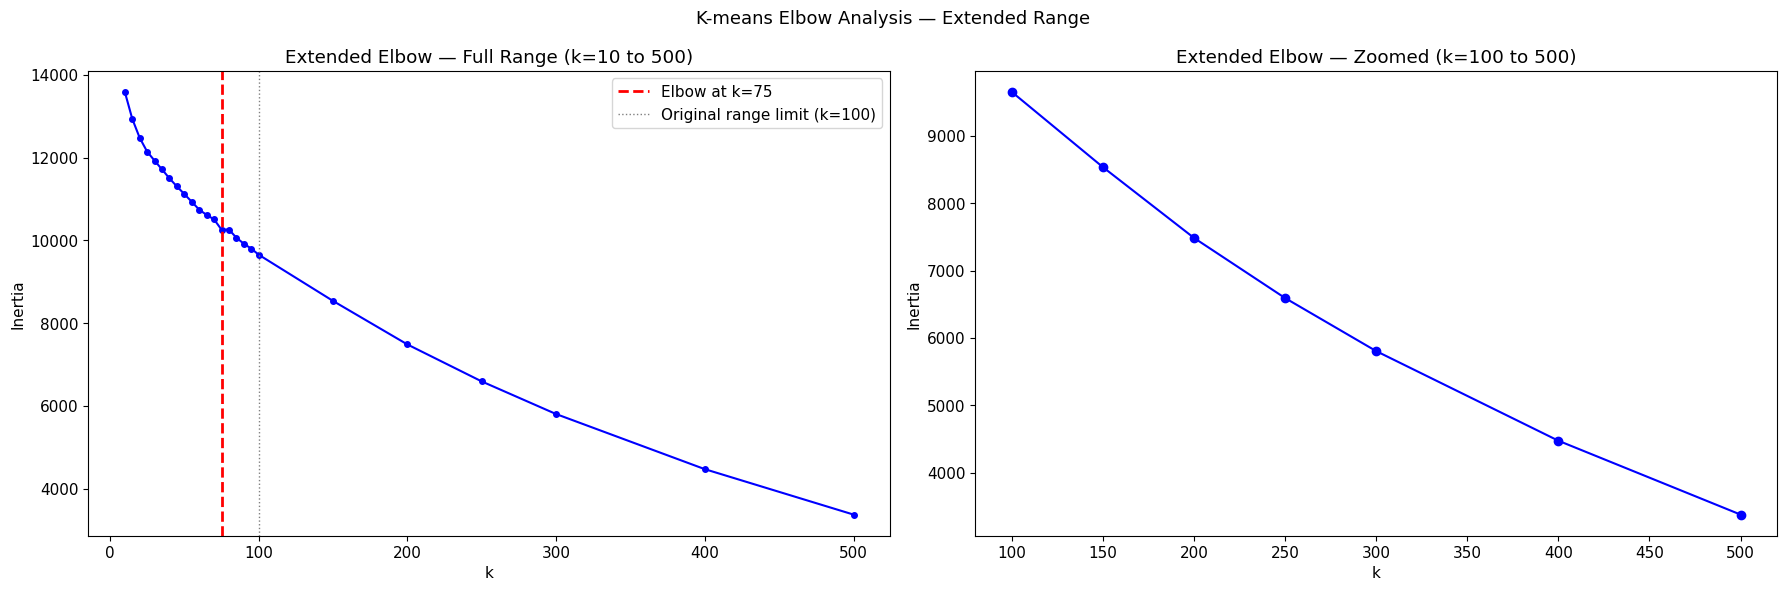

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Full curve
axes[0].plot(k_values_extended, inertias_extended, "bo-", markersize=4)
axes[0].axvline(x=elbow_k_extended, color="red", linestyle="--",
                linewidth=2, label=f"Elbow at k={elbow_k_extended}")
axes[0].axvline(x=100, color="gray", linestyle=":", linewidth=1,
                label="Original range limit (k=100)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Extended Elbow — Full Range (k=10 to 500)")
axes[0].legend()

# Zoomed: k=100 to 500
k_high = [k for k in k_values_extended if k >= 100]
inertia_high = [inertias_extended[i] for i, k in enumerate(k_values_extended) if k >= 100]
axes[1].plot(k_high, inertia_high, "bo-", markersize=6)
axes[1].set_xlabel("k")
axes[1].set_ylabel("Inertia")
axes[1].set_title("Extended Elbow — Zoomed (k=100 to 500)")

plt.suptitle("K-means Elbow Analysis — Extended Range", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/phase1/coverage/elbow_extended.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
import umap
import hdbscan
import numpy as np

print("Fitting UMAP 10D on corpus (2-3 minutes)...")
reducer_10d = umap.UMAP(
    n_components=10,
    n_neighbors=15,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
    verbose=False
)
corpus_10d = reducer_10d.fit_transform(corpus_embeddings)
query_10d = reducer_10d.transform(query_embeddings)

print(f"Corpus 10D shape: {corpus_10d.shape}")
print(f"Query 10D shape:  {query_10d.shape}")

print("\nRunning HDBSCAN (min_cluster_size=50, min_samples=5)...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)
corpus_labels = clusterer.fit_predict(corpus_10d)

from collections import Counter
n_clusters = len(set(corpus_labels)) - (1 if -1 in corpus_labels else 0)
n_noise = (corpus_labels == -1).sum()

print(f"\nHDBSCAN Results:")
print(f"  Clusters found: {n_clusters}")
print(f"  Noise points:   {n_noise} ({n_noise/len(corpus_labels):.1%})")
print(f"\nCluster sizes:")
for label, count in sorted(Counter(corpus_labels).items()):
    tag = "NOISE" if label == -1 else f"Cluster {label}"
    print(f"  {tag}: {count} chunks")

Fitting UMAP 10D on corpus (2-3 minutes)...
Corpus 10D shape: (18840, 10)
Query 10D shape:  (100, 10)

Running HDBSCAN (min_cluster_size=50, min_samples=5)...

HDBSCAN Results:
  Clusters found: 123
  Noise points:   7606 (40.4%)

Cluster sizes:
  NOISE: 7606 chunks
  Cluster 0: 57 chunks
  Cluster 1: 395 chunks
  Cluster 2: 96 chunks
  Cluster 3: 75 chunks
  Cluster 4: 60 chunks
  Cluster 5: 61 chunks
  Cluster 6: 50 chunks
  Cluster 7: 50 chunks
  Cluster 8: 80 chunks
  Cluster 9: 85 chunks
  Cluster 10: 153 chunks
  Cluster 11: 51 chunks
  Cluster 12: 107 chunks
  Cluster 13: 90 chunks
  Cluster 14: 56 chunks
  Cluster 15: 59 chunks
  Cluster 16: 52 chunks
  Cluster 17: 75 chunks
  Cluster 18: 86 chunks
  Cluster 19: 116 chunks
  Cluster 20: 59 chunks
  Cluster 21: 60 chunks
  Cluster 22: 144 chunks
  Cluster 23: 57 chunks
  Cluster 24: 52 chunks
  Cluster 25: 51 chunks
  Cluster 26: 65 chunks
  Cluster 27: 57 chunks
  Cluster 28: 77 chunks
  Cluster 29: 61 chunks
  Cluster 30: 119 

In [19]:
print(f"HDBSCAN validity score (DBCV): {clusterer.relative_validity_}")

AttributeError: Minimum spanning tree not present. Either HDBSCAN object was created with gen_min_span_tree=False or the tree was not generated in spite of it owing to internal optimization criteria.

In [20]:
print(f"DBCV validity score: {clusterer.relative_validity_:.4f}")

AttributeError: Minimum spanning tree not present. Either HDBSCAN object was created with gen_min_span_tree=False or the tree was not generated in spite of it owing to internal optimization criteria.

In [21]:
import hdbscan
import numpy as np

print("Rerunning HDBSCAN with gen_min_span_tree=True for validation...")
clusterer_validated = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
    gen_min_span_tree=True  # Required for DBCV score
)
clusterer_validated.fit(corpus_10d)

# Confirm same results as before
from collections import Counter
labels = clusterer_validated.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()
print(f"Clusters found: {n_clusters}")
print(f"Noise points:   {n_noise} ({n_noise/len(labels):.1%})")

# The key validation metric
dbcv = clusterer_validated.relative_validity_
print(f"\nDBCV validity score: {dbcv:.4f}")
print(f"Interpretation:")
print(f"  > 0.5  : Good clustering")
print(f"  0 - 0.5: Moderate clustering")
print(f"  < 0    : Worse than random — clustering is not meaningful")

Rerunning HDBSCAN with gen_min_span_tree=True for validation...
Clusters found: 123
Noise points:   7606 (40.4%)

DBCV validity score: 0.2084
Interpretation:
  > 0.5  : Good clustering
  0 - 0.5: Moderate clustering
  < 0    : Worse than random — clustering is not meaningful
